In [4]:
!pip install -q transformers
!pip install -q opendatasets

import opendatasets as od
od.download("https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection")


ERROR: Operation cancelled by user
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: rehman047
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection


100%|██████████| 3.30M/3.30M [00:00<00:00, 894MB/s]

In [7]:
import torch
import torch.nn as nn
from torch.optim import Adam
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

device="cuda" if torch.cuda.is_available() else "cpu"

In [8]:
device

'cuda'

In [59]:
df=pd.read_json("/content/news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset.json",lines=True)
#"/content/news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset.json"

In [60]:
df.head()

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0


In [61]:
df.shape

(26709, 3)

In [62]:
df.isnull().sum()

,0
article_link,0
headline,0
is_sarcastic,0


In [63]:
df=df.dropna()
df=df.drop_duplicates()

In [64]:
df.shape

(26708, 3)

In [65]:
df.head()

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0


In [66]:
df.drop("article_link",axis=1,inplace=True)

In [67]:
df.head()

,headline,is_sarcastic
0,former versace store clerk sues over secret 'b...,0
1,the 'roseanne' revival catches up to our thorn...,0
2,mom starting to fear son's web series closest ...,1
3,"boehner just wants wife to listen, not come up...",1
4,j.k. rowling wishes snape happy birthday in th...,0


In [68]:
df['is_sarcastic'].value_counts()

,count
is_sarcastic,
0,14984
1,11724


In [69]:
df.is_sarcastic=df["is_sarcastic"].map({0:"not-sarcastic",1:"sarcastic"})

In [70]:
df['is_sarcastic'].value_counts()

,count
is_sarcastic,
not-sarcastic,14984
sarcastic,11724


<Axes: ylabel='count'>

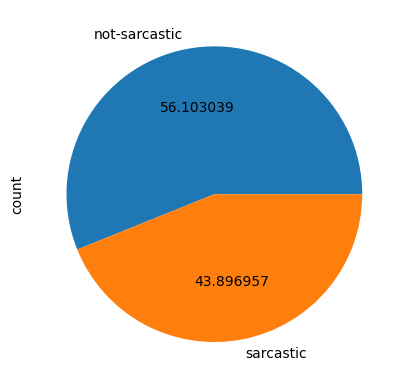

In [73]:
df['is_sarcastic'].value_counts().plot(kind="pie",autopct="%f")

In [72]:
df.head()

,headline,is_sarcastic
0,former versace store clerk sues over secret 'b...,not-sarcastic
1,the 'roseanne' revival catches up to our thorn...,not-sarcastic
2,mom starting to fear son's web series closest ...,sarcastic
3,"boehner just wants wife to listen, not come up...",sarcastic
4,j.k. rowling wishes snape happy birthday in th...,not-sarcastic


In [74]:
df.is_sarcastic=df["is_sarcastic"].map({"not-sarcastic":0,"sarcastic":1})

In [75]:
df.head()

,headline,is_sarcastic
0,former versace store clerk sues over secret 'b...,0
1,the 'roseanne' revival catches up to our thorn...,0
2,mom starting to fear son's web series closest ...,1
3,"boehner just wants wife to listen, not come up...",1
4,j.k. rowling wishes snape happy birthday in th...,0


In [77]:
X_train,X_test,Y_train,Y_test=train_test_split(df['headline'].values,df['is_sarcastic'].values,test_size=0.3)
X_val,X_test,Y_val,Y_test=train_test_split(X_test,Y_test,test_size=0.5)

In [78]:
X_train.shape

(18695,)

In [79]:
X_train

array(['closed-door meeting to determine future of honey-roasted peanuts',
       '2018 is already off to a violent start',
       '10th-grade class watches ben-hur for two weeks', ...,
       'arctic glacier called to melt before senate energy committee',
       'car bomb kills three in southeastern turkey',
       'white terror demands white action: what allies need to do right now for charlottesville'],
      dtype=object)

In [80]:
Y_train

array([1, 0, 1, ..., 1, 0, 0])